Sentiment and text analysis from the survey open questions. Participants expressed their opinion about:
1) Advantages using a maritime assistant (autonomous navigation + XAI)
2) Disadvantages using a maritime assistant (autonomous navigation + XAI)
3) General feedback and opinions

In [ ]:
# Import pandas to handle data
import pandas as pd

# Load the csv file into a pandas dataframe
df = pd.read_csv('/content/AHOI_Survey_HumanAITeaming_FINISHED_TRUE_values.csv')

# Select only the columns that are of object (text) data type
text_df = df.select_dtypes(include=['object'])

# Optional for quick check: display the first 5 rows of the new DataFrame with text columns
# display(text_df.head())
# Select only the specified columns from text_df
selected_text_df = text_df[['advantages', 'disadvantages', 'feedback']]

# Optional for quick check: display the first 5 rows of the new DataFrame
# display(selected_text_df.head())

Set up to preprocess text data and to visualize open question feedback in wordclouds.

For sentiment analysis:
Advantages = positive sentiment
Disadvantages = negative sentiment
Feedback = both positive and negative connoted words.

In [ ]:
# Import necessary libraries for text analysis
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# Download NLTK stopwords
nltk.download('stopwords')

In [ ]:
# Fill NaN values with empty strings in the selected text columns
selected_text_df_cleaned = selected_text_df.fillna('')

# Combine all text from 'advantages', 'disadvantages', and 'feedback' into a single string
all_text = ' '.join(selected_text_df_cleaned['advantages'] + ' ' +
                    selected_text_df_cleaned['disadvantages'] + ' ' +
                    selected_text_df_cleaned['feedback'])

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespaces
    return text

processed_text = preprocess_text(all_text)

# Ensure stopwords are available and define stop_words
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True) # Ensure download happens if not already, suppress output
stop_words = set(stopwords.words('english'))

words = processed_text.split()
filtered_words = [word for word in words if word not in stop_words and len(word) > 2] # Remove short words
final_text = ' '.join(filtered_words)

print(f"Original text length: {len(all_text)}")
print(f"Processed text length (after cleaning and stopword removal): {len(final_text)}")

In [ ]:
# Ensure final_text is defined by re-running the aggregation if needed
if 'final_text' not in globals():
    # Fallback to ensure the cell can run independently if previous cell wasn't run
    selected_text_df_cleaned = selected_text_df.fillna('')
    all_text = ' '.join(selected_text_df_cleaned['advantages'] + ' ' + selected_text_df_cleaned['disadvantages'] + ' ' + selected_text_df_cleaned['feedback'])
    temp_processed = preprocess_text(all_text)
    final_text = ' '.join([word for word in temp_processed.split() if word not in stop_words and len(word) > 2])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(final_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Advantages, Disadvantages, and Feedback')
plt.show()

In [ ]:
# Ensure dependencies and helper functions are available
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespaces
    return text

# Extract text from 'advantages' column
advantages_text = ' '.join(selected_text_df_cleaned['advantages'])

# Preprocess the 'advantages' text
processed_advantages_text = preprocess_text(advantages_text)

# Remove stopwords from 'advantages' text
words_advantages = processed_advantages_text.split()
filtered_words_advantages = [word for word in words_advantages if word not in stop_words and len(word) > 2]
final_text_advantages = ' '.join(filtered_words_advantages)

# Optional print cmd for quick checks
#print(f"Original 'advantages' text length: {len(advantages_text)}")
#print(f"Processed 'advantages' text length: {len(final_text_advantages)}")

Analysis of **advantages** using a maritime assistant (with XAI).

In [ ]:
# Generate a word cloud for 'advantages' column
wordcloud_advantages = WordCloud(width=800, height=400, background_color='white').generate(final_text_advantages)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_advantages, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Advantages')
plt.show()

In [ ]:
from collections import Counter

# Calculate word frequencies for the 'advantages' column
word_freq_advantages = Counter(filtered_words_advantages)

# Get the 20 most common words
most_common_advantages = word_freq_advantages.most_common(20)

# Convert to a data frame for better display
freq_df = pd.DataFrame(most_common_advantages, columns=['Word', 'Frequency'])

print("Top 20 most common words in 'advantages':")
display(freq_df)

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt_tab', quiet=True)

sia = SentimentIntensityAnalyzer()

# Filter out meta-rows and handle missing values
quotes_df = selected_text_df_cleaned[~selected_text_df_cleaned['advantages'].str.contains('{"ImportId"|Do you see advantages', na=False)]

# Split text into sentences and score them
all_sentences = []
for text in quotes_df['advantages']:
    if text.strip():
        sentences = nltk.sent_tokenize(text)
        for sent in sentences:
            score = sia.polarity_scores(sent)['compound']
            all_sentences.append({'sentence': sent.strip(), 'score': score})

# Sort by highest compound score
positive_quotes = pd.DataFrame(all_sentences).sort_values(by='score', ascending=False)

print("Most positive sentences/quotes from 'advantages':")
display(positive_quotes.head(10))

In [ ]:
# Save the positive quotes table to a csv file
positive_quotes.to_csv('sentiment_advantages.csv', index=False)
print("File 'sentiment_advantages.csv' has been saved.")

Analysis on **disadvantages** using a maritime assistant.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Extract and clean 'disadvantages' text
disadvantages_text = ' '.join(selected_text_df_cleaned['disadvantages'])
processed_disadvantages = preprocess_text(disadvantages_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_disadvantages = [w for w in processed_disadvantages.split() if w not in stop_words and len(w) > 2]
final_text_disadvantages = ' '.join(filtered_disadvantages)

# Generate Word Cloud
wordcloud_dis = WordCloud(width=800, height=400, background_color='white').generate(final_text_disadvantages)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_dis, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Disadvantages')
plt.show()

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Filter meta-rows for disadvantages
dis_quotes_df = selected_text_df_cleaned[~selected_text_df_cleaned['disadvantages'].str.contains('{"ImportId"|Do you see disadvantages', na=False)]

all_dis_sentences = []
for text in dis_quotes_df['disadvantages']:
    if text.strip():
        sentences = nltk.sent_tokenize(text)
        for sent in sentences:
            score = sia.polarity_scores(sent)['compound']
            all_dis_sentences.append({'sentence': sent.strip(), 'score': score})

# Sort by lowest compound score for negative quotes
negative_quotes = pd.DataFrame(all_dis_sentences).sort_values(by='score', ascending=True)

print("Most negative sentences/quotes from 'disadvantages':")
display(negative_quotes.head(10))

# # Save negatives quotes table to a new csv file
negative_quotes.to_csv('sentiment_disadvantages.csv', index=False)
print("\nFile 'sentiment_disadvantages.csv' has been saved.")

(Pre)Processing of feedback text.

In [ ]:
# Extract and clean 'feedback' text
feedback_text = ' '.join(selected_text_df_cleaned['feedback'])
processed_feedback = preprocess_text(feedback_text)

# Remove stopwords
filtered_feedback = [w for w in processed_feedback.split() if w not in stop_words and len(w) > 2]
final_text_feedback = ' '.join(filtered_feedback)

# Generate Word Cloud for feedback
if final_text_feedback.strip():
    wordcloud_feedback = WordCloud(width=800, height=400, background_color='white').generate(final_text_feedback)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_feedback, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Feedback')
    plt.show()
else:
    print('No text found in the feedback column to generate a word cloud.')

In [ ]:
# Filter meta-rows for feedback
feedback_quotes_df = selected_text_df_cleaned[~selected_text_df_cleaned['feedback'].str.contains('{"ImportId"|Do you have any further feedback', na=False)]

all_feedback_sentences = []
for text in feedback_quotes_df['feedback']:
    if text.strip():
        sentences = nltk.sent_tokenize(text)
        for sent in sentences:
            score = sia.polarity_scores(sent)['compound']
            all_feedback_sentences.append({'sentence': sent.strip(), 'score': score})

# Check if there are sentences to display
if all_feedback_sentences:
    negative_feedback_quotes = pd.DataFrame(all_feedback_sentences).sort_values(by='score', ascending=True)

    print("Most negative sentences/quotes from 'feedback':")
    display(negative_feedback_quotes.head(10))

    # Save to CSV
    negative_feedback_quotes.to_csv('sentiment_feedback.csv', index=False)
    print("\nFile 'sentiment_feedback.csv' has been saved.")
else:
    print('No valid sentences found in the feedback column for sentiment analysis.')

In [ ]:
from collections import Counter

# Calculate word frequencies for feedback
word_freq_feedback = Counter(filtered_feedback)
# Get 20 most common words for the word cloud
most_common_feedback_20 = dict(word_freq_feedback.most_common(20))

# Generate a word cloud based on frequency
wordcloud_freq = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(most_common_feedback_20)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_freq, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top 20 Feedback Words')
plt.show()

In [ ]:
# Sort feedback sentences by sentiment score
if all_feedback_sentences:
    feedback_results = pd.DataFrame(all_feedback_sentences).sort_values(by='score', ascending=False)

    # Extract top 10 positive and top 10 negative
    top_positive = feedback_results.head(10).copy()
    top_negative = feedback_results.tail(10).copy().sort_values(by='score')

    print("--- Top 10 Positive Feedback Phrases ---")
    display(top_positive)

    print("\n--- Top 10 Negative Feedback Phrases ---")
    display(top_negative)

    # Save combined results
    combined_feedback = pd.concat([top_positive, top_negative])
    combined_feedback.to_csv('feedback_sentiment_summary.csv', index=False)
else:
    print('No feedback sentences found to analyze.')

In [ ]:
print("--- Top 10 Negative Feedback Phrases ---")
display(top_negative[['sentence', 'score']])

Refinement for word clouds to display only **semantically meaningful** words in the "advantages" (positive sentiment) and "disadvantages" (negative sentiment) text comments.

In [ ]:
from collections import Counter

# Define semantically useful positive words and their common variations/misspellings
positive_keywords = [
    'useful', 'usefull', 'confidence', 'aid', 'guidance', 'assistant',
    'help', 'support', 'clear', 'improve', 'better', 'decision',
    'navigation', 'bridge', 'officer', 'master', 'situation',
    'correctly', 'wisely', 'quick', 'suggestions', 'assist'
]

# Get the top positive sentences (compound score > 0.4)
positive_sentences = positive_quotes[positive_quotes['score'] > 0.4]['sentence'].str.lower()

# Extract only the specified keywords from these sentences
all_positive_words = []
for sent in positive_sentences:
    # Use regex to find whole words matching our keywords
    found = [word for word in positive_keywords if re.search(rf'\b{word}\b', sent)]
    all_positive_words.extend(found)

# Count frequencies
pos_word_freq = Counter(all_positive_words)

if pos_word_freq:
    wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pos_word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_pos, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Semantically Useful Positive Advantages')
    plt.show()
else:
    print('No matching positive keywords found to generate the word cloud.')

In [ ]:
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Define keywords related to concerns or risks in disadvantages
negative_keywords = [
    'reliance', 'overreliance', 'trust', 'blindly', 'risk', 'lazy', 'attention',
    'error', 'failure', 'wrong', 'dangerous', 'skill', 'loss', 'critical',
    'complacency', 'system', 'limitations', 'sensors', 'faulty', 'collision'
]

# Get negative sentences (compound score < -0.3)
negative_sentences_list = negative_quotes[negative_quotes['score'] < -0.3]['sentence'].str.lower()

# Filter keywords
all_neg_words = []
for sent in negative_sentences_list:
    found = [word for word in negative_keywords if re.search(rf'\b{word}\b', sent)]
    all_neg_words.extend(found)

neg_word_freq = Counter(all_neg_words)

if neg_word_freq:
    wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate_from_frequencies(neg_word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('Semantic Word Cloud of Key Disadvantages/Risks')
    plt.show()
else:
    print('No matching negative keywords found.')

Visualize top-k most words (uni-grams) describing 'advantage'/'disadvantages' used by all age groups. (here:k=5; change this parameter when calling the "get_top_n_gram()" function; change n=1 accordingly to get bi-grams, etc.)

In [ ]:
def get_top_n_grams(corpus, n=1, top_k=10):
    # Filter out empty strings from corpus before vectorization
    filtered_corpus = [doc for doc in corpus if doc.strip()]
    if not filtered_corpus:
        return [] # Return empty list if corpus becomes empty after filtering
    vec = CountVectorizer(ngram_range=(n, n)).fit(filtered_corpus)
    bag_of_words = vec.transform(filtered_corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Group by age and extract top 5 unigrams for 'advantages' and 'disadvantages'

print("\nTop 5 Unigrams for 'Advantages' by Age Group:")
for age_group in sorted(df_cleaned['age'].dropna().unique()):
    corpus = df_cleaned[df_cleaned['age'] == age_group]['advantages_processed']
    top_unigrams = get_top_n_grams(corpus, n=1, top_k=5)
    if top_unigrams:
        print(f"Age Group {int(age_group)}: {top_unigrams}")

print("\nTop 5 Unigrams for 'Disadvantages' by Age Group:")
for age_group in sorted(df_cleaned['age'].dropna().unique()):
    corpus = df_cleaned[df_cleaned['age'] == age_group]['disadvantages_processed']
    top_unigrams = get_top_n_grams(corpus, n=1, top_k=5)
    if top_unigrams:
        print(f"Age Group {int(age_group)}: {top_unigrams}")


Top 5 Unigrams for 'Advantages' by Age Group:
Age Group 1: [('situation', np.int64(4)), ('vessel', np.int64(3)), ('assistant', np.int64(3)), ('call', np.int64(3)), ('master', np.int64(3))]
Age Group 2: [('situation', np.int64(13)), ('assistant', np.int64(7)), ('decision', np.int64(7)), ('tool', np.int64(6)), ('vessel', np.int64(5))]
Age Group 3: [('officer', np.int64(5)), ('making', np.int64(5)), ('decision', np.int64(5)), ('action', np.int64(3)), ('guidance', np.int64(2))]
Age Group 4: [('assistant', np.int64(9)), ('oow', np.int64(5)), ('decision', np.int64(3)), ('clearly', np.int64(3)), ('advice', np.int64(3))]
Age Group 5: [('assistant', np.int64(7)), ('situation', np.int64(7)), ('maritime', np.int64(4)), ('oow', np.int64(4)), ('decision', np.int64(4))]

Top 5 Unigrams for 'Disadvantages' by Age Group:
Age Group 1: [('assistant', np.int64(4)), ('situation', np.int64(4)), ('oow', np.int64(3)), ('overreliance', np.int64(2)), ('read', np.int64(2))]
Age Group 2: [('assistant', np.int64

Visualize top-k most words describing 'advantage'/'disadvantages' used by all age groups. (here:k=15)

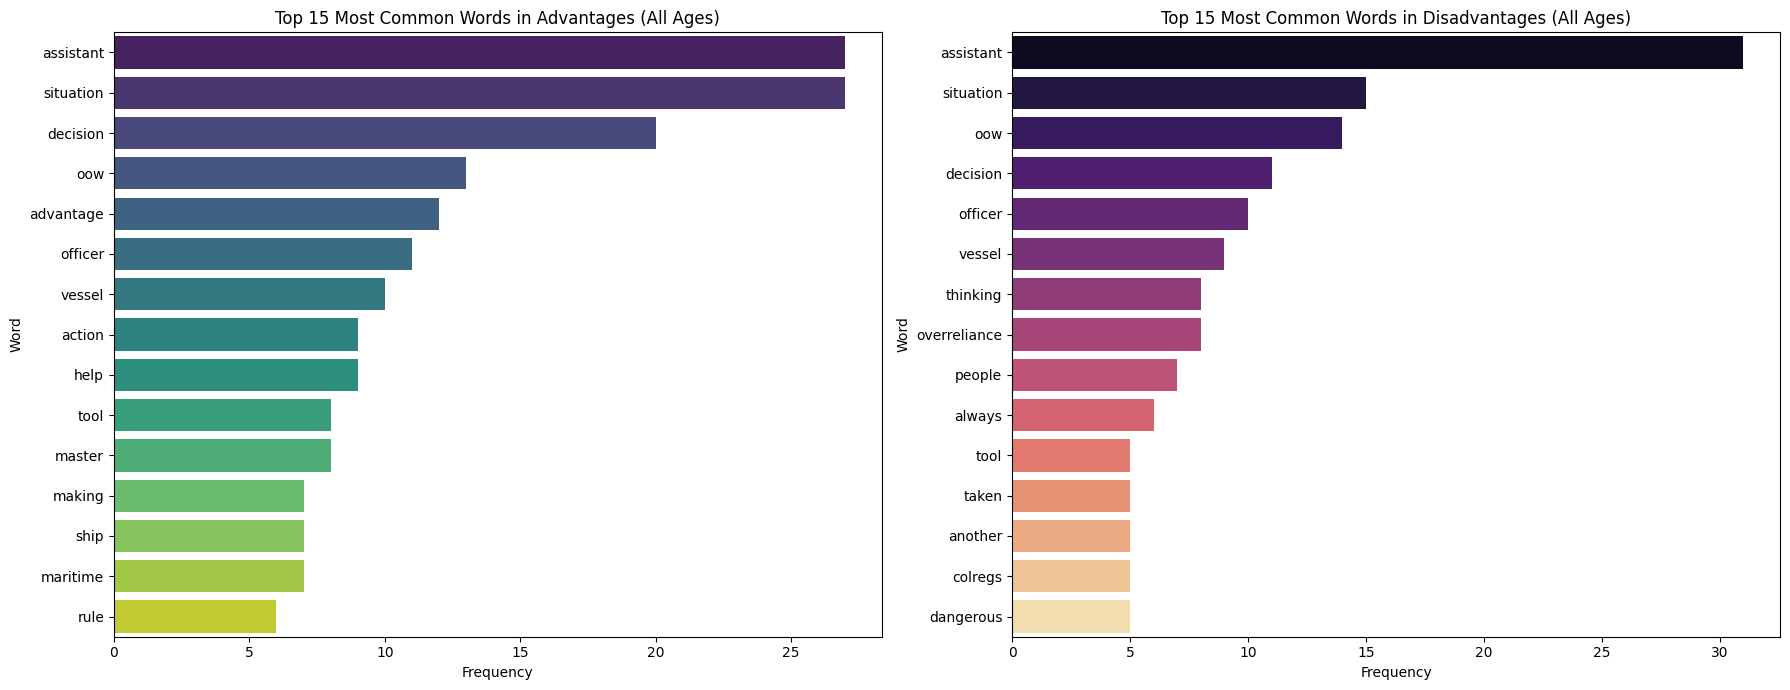

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# For Advantages
common_words_advantages = get_top_n_grams(df_cleaned['advantages_processed'], n=1, top_k=15)
df_common_advantages = pd.DataFrame(common_words_advantages, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=df_common_advantages, ax=axes[0], palette='viridis', hue='Word', legend=False)
axes[0].set_title('Top 15 Most Common Words in Advantages (All Ages)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Word')

# For Disadvantages
common_words_disadvantages = get_top_n_grams(df_cleaned['disadvantages_processed'], n=1, top_k=15)
df_common_disadvantages = pd.DataFrame(common_words_disadvantages, columns=['Word', 'Count'])
sns.barplot(x='Count', y='Word', data=df_common_disadvantages, ax=axes[1], palette='magma', hue='Word', legend=False)
axes[1].set_title('Top 15 Most Common Words in Disadvantages (All Ages)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Word')

plt.tight_layout()
plt.show()

In [ ]:
unique_fb_words = sorted(list(set(all_fb_words)))
print("Keywords from 'feedback_keywords' found in the data:")
print(unique_fb_words)

In [ ]:
print("All words included in the 'feedback_keywords' list:")
print(feedback_keywords)

In [ ]:
# Create a dictionary where every keyword has an equal frequency for visualization
full_keyword_freq = {word: 1 for word in feedback_keywords}

wordcloud_all = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate_from_frequencies(full_keyword_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All Predefined Feedback Keywords')
plt.show()

In [ ]:
# Define keywords related to technical feedback or improvements
feedback_keywords = [
    'display', 'interface', 'color', 'indicator', 'alarm', 'sound', 'voice',
    'predictor', 'logic', 'training', 'screen', 'visible', 'clear', 'confusing',
    'improve', 'suggestion', 'information', 'options', 'automation'
]

# Use all feedback sentences as it is often a mix of neutral/suggestion text
feedback_sentences_list = pd.DataFrame(all_feedback_sentences)['sentence'].str.lower()

all_fb_words = []
for sent in feedback_sentences_list:
    found = [word for word in feedback_keywords if re.search(rf'\b{word}\b', str(sent))]
    all_fb_words.extend(found)

fb_word_freq = Counter(all_fb_words)

if fb_word_freq:
    wordcloud_fb = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(fb_word_freq)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud_fb, interpolation='bilinear')
    plt.axis('off')
    plt.title('Semantic Word Cloud of Technical Feedback & Suggestions')
    plt.show()
else:
    print('No matching feedback keywords found.')